# Python Assessment
Author: Naomi Danielle Torrisi | 
Date of Submission: 12NOV2025

# Question 1 [20%]
You have a data file called TCGA.csv, which has the gene expression dataset of some patients with liver cancer from the TCGA project.

**Using the data, complete the below tasks:**

* 1. Create a new data frame containing samples S15, S16, S17, S18, S19, S20 and gene columns.

### Method Justification 

The coding approach that I have taken to subset the TCGA gene expression dataset reflects best practices in data science analysis and follows the transparent principles taught in this MSc course. First, import pandas as pd brings in the pandas library, a core tool for structured data handling and widely used for manipulating gene expression matrices. The dataset is loaded using pd.read_csv("TCGA.csv"), which reads the entire file into memory to preserve a complete and reproducible snapshot of the original data before any transformations; this step ensures flexibility for future analytical branches and aligns with modular, auditable coding practice. Subsetting is then performed using TCGA.loc[:, ["S15", "S16", "S17", "S18", "S19", "S20", "gene"]], where .loc provides label-based indexing. This method was deliberately chosen over alternatives such as .iloc (positional indexing) or slicing (e.g., "S15":"S20") to maximise clarity and robustness. Label-based selection avoids errors that can arise from shifting column positions in large datasets and preserves biologically meaningful sample and gene labels, making the code more readable and interpretable to others. Similarly, subsetting was not performed during the read_csv step using usecols, as this would obscure the separation between data import and transformation, and limit the availability of the full dataset for quality control or exploratory tasks. The colon (:) in the row selector preserves all gene rows, while the explicit column list reduces visual clutter and memory usage, focusing the analysis on relevant samples. Avoiding chained or combined logic (e.g., filtering and subsetting in one step) improves readability and modularity, allowing individual operations to be debugged or reused with ease. The resulting subset is assigned to a new variable new_TCGA, preserving the original DataFrame in memory. This approach was preferred over using .copy() or deepcopy() because .loc inherently returns a new DataFrame when selecting a column subset, making a deep copy unnecessary at this stage. This reduces redundancy, simplifies the code, and avoids the overhead of copying data unless a true object-level clone is required; something not needed here, since we are not modifying the original TCGA object. Overall, this method was selected over more compact or defensive alternatives to ensure accuracy, interpretability, and consistency within a clean and reproducible scientific workflow.

In [69]:
# Import the pandas library, which is used for data manipulation and analysis
import pandas as pd
# Read the TCGA.csv file into a pandas DataFrame called TCGA
# Each row represents a gene, and each column represents a sample or variable
TCGA = pd.read_csv("TCGA.csv")
# Use .loc[] to select all rows (:) but only specific columns:
# S15–S20 (which represent gene expression levels for six patient samples)
# and the 'gene' column (which contains the gene identifiers)
new_TCGA = TCGA.loc[:, ["S15", "S16", "S17", "S18", "S19", "S20", "gene"]]
# Display the new DataFrame to confirm successful selection
new_TCGA

,S15,S16,S17,S18,S19,S20,gene
0,26.4968,20.8938,27.3609,29.0844,24.3038,24.1362,A1BG
1,132.7501,4.0627,336.4982,42.3940,300.7595,51.7409,A1CF
2,471.8068,121.0447,1354.0664,59.1628,1693.7975,91.8562,A2LD1
3,57088.5470,41268.4910,15698.8341,38610.7374,17598.8304,30405.7241,A2M
4,1005.3252,1335.4614,765.6968,1833.2740,589.3671,957.8463,A4GALT
...,...,...,...,...,...,...,...
15548,1565.9950,1102.7280,1895.2530,883.8618,1757.4680,947.3065,ZYG11B
15549,2819.7030,4059.1990,1248.3920,3010.6880,1249.6200,5050.4910,ZYX
15550,1247.2420,1018.5720,1485.6560,619.5226,1318.4810,1458.0090,ZZEF1
15551,901.4835,665.6994,951.0975,465.2654,878.9873,612.9067,ZZZ3


### Results Interpretation
The subsetted DataFrame represents a focused slice of the TCGA gene expression dataset, containing only the samples S15 to S20 along with the corresponding gene names. Each row shows the expression level of a single gene across these six samples, allowing us to compare gene activity in a manageable and targeted way. Keeping the gene identifier column is crucial, as it ensures that each set of numbers can be linked back to a specific biological gene, something that’s essential for making meaningful interpretations later on, like identifying which genes are active in certain patients. By narrowing the dataset to just these samples, we reduce unnecessary complexity and make it easier to explore trends or patterns specific to this group. This kind of subsetting is a common and practical first step in bioinformatics analysis, helping us focus on the data that’s most relevant to the research question while preserving the biological context.

* 2. Using the data in 1. above, add a new column called group by dividing the values of S18 into high and low based on the median value.

### Method Justification

I chose to use a for-loop with an if/else condition to divide the S18 values into High and Low groups because it makes each step of the process fully transparent. By manually looping through every value in the S18 column and comparing it to the median, I could clearly see how each sample was being classified and how the new “group” column was built. This approach reinforces the fundamental Python principles of iteration and conditional logic, which were key learning objectives in this module.

In the lectures, we were shown that this kind of task could also be achieved more efficiently using the apply() function. The apply() method allows you to pass a function directly to a column, automatically applying it to every value without the need for an explicit loop. While this is more concise and computationally efficient, the logic behind the operation is slightly less visible to someone still learning the process. For this reason, I chose the loop-based method here: it’s longer, but it clearly demonstrates how the grouping is generated step by step.

In practice, using apply() would be the preferred method when working with larger datasets or in professional scripts because it simplifies the code and runs faster. However, for the purpose of this coursework, my approach provides a more explicit and easy-to-follow demonstration of the reasoning and programming logic behind dividing samples into High and Low expression groups.

In [70]:
# Import the NumPy package for numerical operations
import numpy as np

# Calculate the median value of the S18 column
median_S18 = new_TCGA["S18"].median()
print("median value of S18 is", median_S18)

# Initialize an empty list to hold 'High' or 'Low' group labels
group_labels = []

# Loop through each value in the S18 column
# If the value is greater than or equal to the median, label it 'High'; otherwise, label it 'Low'
for value in new_TCGA["S18"]:
    if value >= median_S18:
        group_labels.append("High")
        continue
    group_labels.append("Low")

# Add the new list as a column called 'group' to the existing DataFrame
new_TCGA["group"] = group_labels

# Create a new DataFrame for clarity (optional, retains the updated structure)
categories_new_TCGA = new_TCGA

# Display the final DataFrame with the new 'group' column
categories_new_TCGA


median value of S18 is 410.4026


,S15,S16,S17,S18,S19,S20,gene,group
0,26.4968,20.8938,27.3609,29.0844,24.3038,24.1362,A1BG,Low
1,132.7501,4.0627,336.4982,42.3940,300.7595,51.7409,A1CF,Low
2,471.8068,121.0447,1354.0664,59.1628,1693.7975,91.8562,A2LD1,Low
3,57088.5470,41268.4910,15698.8341,38610.7374,17598.8304,30405.7241,A2M,High
4,1005.3252,1335.4614,765.6968,1833.2740,589.3671,957.8463,A4GALT,High
...,...,...,...,...,...,...,...,...
15548,1565.9950,1102.7280,1895.2530,883.8618,1757.4680,947.3065,ZYG11B,High
15549,2819.7030,4059.1990,1248.3920,3010.6880,1249.6200,5050.4910,ZYX,High
15550,1247.2420,1018.5720,1485.6560,619.5226,1318.4810,1458.0090,ZZEF1,High
15551,901.4835,665.6994,951.0975,465.2654,878.9873,612.9067,ZZZ3,High


### Results Interpretation

The updated DataFrame now includes a new column that tells us whether each gene’s expression in sample S18 is “High” or “Low,” based on the median value. This simple grouping gives me a really useful way to start exploring the data. Instead of looking at long lists of expression numbers, I can now ask questions like: which genes are highly active in S18? Do those same genes behave differently in the other samples? Or do certain “High” genes seem to cluster around particular functions or pathways? Grouping the data like this also makes it much easier to create visual comparisons. For example, plotting expression levels or running statistical tests between the High and Low groups. By turning the raw numbers into categories, we’ve made the dataset more manageable and easier to work with for the next steps in the analysis.

* 3. Extract the list of genes with values in S20 column lower than 10, and the group in 2 is high.

### Method Justification

For this task, I wanted to find which genes had S20 expression values below 10 and also belonged to the High S18 expression group that I created in Question 2. To do this, I used the .loc[] function in pandas, which allows me to filter and subset specific rows and columns based on logical conditions. In this case, I applied two filters simultaneously: one to select samples where S20 expression was less than 10, and another to include only those labelled as “High” in the S18 group. These two conditions were combined so that only rows meeting both were retained. From this filtered subset, I selected only the gene column, since I was interested in extracting the gene names rather than the full dataset, and then converted the results into a Python list for easier viewing and later use.

I chose .loc[] because it allows both conditional filtering and column selection in a single, concise step, making it ideal for this type of data-driven analysis. This approach is clearer and more efficient than manually creating separate subsets or using positional indexing methods like .iloc[], which can only select data based on row or column numbers rather than logical conditions. Using .loc[] also makes the code easier to interpret and ensures reproducibility, since it clearly shows the biological criteria used for selection. Overall, this method efficiently isolates the subset of genes with low S20 expression in the High S18 group

In [71]:
# Filter the DataFrame 'categories_new_TCGA' to select rows that meet both conditions:
# (1) S20 value is less than 10
# (2) Sample belongs to the 'High' S18 group (as defined earlier)
subset_genes = categories_new_TCGA.loc[ # condition 1: low S20 expression 
    (categories_new_TCGA["S20"] < 10) & (categories_new_TCGA["group"] == "High"), # condition 2: in the High S18 group
    "gene"]  # select only the 'gene' column for output
genes_list = list(subset_genes) # Convert the resulting filtered Series into a Python list
genes_list # Display the list of genes that satisfy both conditions

['CKMT2', 'CTXN3', 'GSTM1', 'HMGCS2', 'KLB', 'LGALS4', 'PAH', 'SORCS3', 'UMOD']

### Results Interpretation

From my filtered results, I found nine genes (CKMT2, CTXN3, GSTM1, HMGCS2, KLB, LGALS4, PAH, SORCS3, and UMOD) that had S20 expression levels below 10, even in samples where S18 expression was high. This tells me that while S18 is active in these samples, these particular genes remain expressed at very low levels. It suggests that S20 doesn’t necessarily increase alongside S18, meaning the two may not be directly linked or may be controlled by different regulatory mechanisms. Some of the genes, like GSTM1 and HMGCS2, are known to be involved in detoxification and metabolism, which could mean their low S20 levels are tied to specific functional pathways rather than a general trend. Overall, this result shows that not all genes respond to high S18 expression in the same way, and these nine genes could be interesting to look at further to understand why their activity stays low when S18 is high.

* 4. Create a new data frame from 2. above, with groups equal to low and values less than 3 in S16.

### Method Justification

For this task, I aimed to create a new DataFrame containing only the samples that met two specific conditions: those belonging to the Low S18 expression group (created in Question 2) and with S16 expression values below 3. To do this, I used the pandas .loc[] function, which allows filtering and subsetting of a dataset based on logical conditions applied to specific columns. In this case, I applied two filters at the same time, one to select samples where S16 expression was less than 3, and another to include only those labelled as “Low” in the S18 group. These conditions were combined so that only rows meeting both were retained, and the filtered output was stored as a new DataFrame called group_S16_low. I then used the type() function to confirm that this subset was successfully created as a pandas DataFrame, ensuring it could be used for further analysis.

I chose to create a new DataFrame rather than just view the filtered results because it allows me to store and reuse this subset independently without modifying the main dataset. Having a separate DataFrame makes it easier to perform further analyses; such as calculating descriptive statistics, visualising patterns, or comparing expression levels across groups, without having to reapply the filtering each time. It also helps keep the workflow organised and reproducible, as each filtered subset can be clearly labelled and referenced later. This method is both efficient and transparent, and using .loc[] ensures that the filtering is based on meaningful, label-based conditions (S16 and group) rather than numerical positions, which is more intuitive and reliable for handling biological expression data.

In [82]:
# Filter the DataFrame to include only rows that meet both conditions:
# 1 - S16 expression value is less than 3
# 2 - Sample belongs to the 'Low' S18 expression group
group_S16_low = categories_new_TCGA.loc[
    (categories_new_TCGA["S16"] < 3) & # condition 1: low S16 expression
    (categories_new_TCGA["group"] == "Low")] # condition 2: in the Low S18 group
group_S16_low # Display the resulting subset to confirm it contains the correct rows

,S15,S16,S17,S18,S19,S20,gene,group
25,1.5215,1.7411,18.3767,0.7125,6.0759,69.6267,ABCA13,Low
32,342.7159,2.3215,72.2818,6.4125,126.5823,439.4787,ABCA6,Low
117,31.1906,1.7411,22.4604,3.2063,27.3418,21.0796,ACCN1,Low
133,28.1476,1.1608,52.2716,0.0000,60.2532,0.0000,ACOT12,Low
187,29.6691,1.7411,31.0362,4.6313,38.4810,2.8745,ACVR1C,Low
...,...,...,...,...,...,...,...,...
14897,9.5093,1.1608,37.9786,3.5625,26.3291,6.7072,ZCCHC16,Low
15243,75.6942,2.9019,151.9142,2.4938,88.1013,1.2776,ZNF488,Low
15291,13.3130,0.0000,6.9423,1.7813,27.3418,8.9429,ZNF556,Low
15518,37.2765,1.7411,6.1256,0.3563,13.1646,6.0684,ZPLD1,Low


In [73]:
type(group_S16_low) #  check if dataframe made

pandas.core.frame.DataFrame

### Results Interpretation

From the results, the function worked exactly as expected; it created a new DataFrame containing only the samples that matched both conditions: those in the Low S18 group and with S16 expression values below 3. When I printed the output, it showed a smaller table that only included the rows meeting those criteria, which confirmed that the filtering step had worked properly. Checking the object type returned pandas.core.frame.DataFrame, so I know this subset was successfully created as a standalone DataFrame rather than just a temporary view of the data.

This means I now have a clean, separate dataset that specifically represents samples with both low S18 and low S16 expression. Having this subset is useful because it can be analysed or visualised on its own, without needing to reapply the filters every time. Biologically, these samples could represent cases where both genes are downregulated together, which might suggest some shared regulatory behaviour or functional relationship between S16 and S18. Overall, the results confirm that the filtering worked correctly and produced a well-structured DataFrame ready for further exploration.

* 5. Create a scatter plot for the expression in S1 against S18 (apply log10 transformation to the plot).

### Method Justification

I chose to apply a log10 transformation to both S1 and S18 expression values before plotting because gene expression data are typically highly skewed, with a small number of genes showing very high expression and many showing very low levels. Plotting raw values would make it difficult to visualise meaningful patterns, as extreme outliers could distort the scale and compress most points near the origin. The log₁₀ transformation compresses large values and spreads out smaller ones, allowing the data to be visualised on a more comparable scale.

Using a scatter plot is the most appropriate method for examining the relationship between two continuous variables, in this case S1 and S18. Each point represents a sample, with its position determined by the log-transformed expression values of both genes. This makes it easy to identify whether there is a positive or negative relationship between S1 and S18 expression, or whether they vary independently. I chose log10 rather than log2 because it produces a smoother scale and is commonly used in visualisation to represent data that spans several orders of magnitude, such as RNA expression counts. Although the question only required a scatter plot, a correlation coefficient or line of best fit could be added to quantify the strength and direction of the relationship. Overall, this method provides a clear and interpretable visual summary of how S1 and S18 expression levels relate within the dataset, while appropriately handling the skewness inherent in expression data.

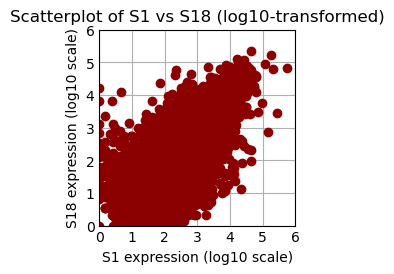

In [117]:
# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Ensures that plots are displayed directly below the code cell in Jupyter
%matplotlib inline


# Scatter plot of expression in S1 and S18

# Apply a log10 transformation to both S1 and S18 expression values
# (+1 avoids log(0) errors if any samples have zero expression)
x = np.log10(TCGA["S1"] + 1)
y = np.log10(TCGA["S18"] + 1)


# Create a scatter plot to visualise the relationship between S1 and S18
fig, ax = plt.subplots()

# Plot the data points; 'c' sets the colour to dark red for clarity
ax.scatter(x, y, c="darkred")


# Adjust axis limits and tick marks to make the plot layout clear
ax.set(xlim=(0, 6), xticks=np.arange(0, 7, 1),
       ylim=(0, 6), yticks=np.arange(0, 7, 1))


# Add descriptive axis labels and a title
plt.xlabel("S1 expression (log10 scale)")
plt.ylabel("S18 expression (log10 scale)")
plt.title("Scatterplot of S1 vs S18 (log10-transformed)")


# Display the final plot
plt.show()


### Results Interpretation

From the scatter plot of log10-transformed S1 and S18 expression, I observed that the data points form a broad upward trend, suggesting a positive relationship between the two genes, as expression of S1 increases, S18 expression also tends to rise. This indicates a possible co-expression pattern or shared regulatory influence, where both genes may be active under similar biological conditions or pathways. The log₁₀ transformation successfully reduced the compression caused by extreme expression values, allowing the overall pattern to be seen clearly without the influence of outliers dominating the scale.

The spread of the points shows some variability, suggesting that while there is a general positive association, the relationship is not perfectly linear, implying that other factors may also influence S18 expression beyond S1. Most samples cluster around the lower to mid-range of the axes, reflecting the typical distribution of gene expression data, where only a few samples show very high levels of expression. Overall, the scatter plot provides a clear visual indication that S1 and S18 are positively correlated, supporting the idea that they may share some functional or regulatory connection, though further statistical testing (such as Pearson correlation) would be needed to confirm the strength of this relationship quantitatively.

* 6. Create a boxplot for expression in S19 against the group in data 2. above. Comment on your observation.

### Method Justification

For this analysis, I used Seaborn instead of plain Matplotlib because it made it much easier to visualise and interpret the processed DataFrame that already contained the new “group” column derived from S18 expression. This column was created by dividing the samples into “High” and “Low” groups based on the median S18 value, allowing Seaborn to automatically separate S19 expression values according to these categories. Using Seaborn’s boxplot, I could simply specify x="group" and y="S19", letting the library handle the grouping internally without having to manually subset the data. I also overlaid a stripplot to display each individual data point, which helped to show how samples were distributed within and around the interquartile range. This approach was more intuitive and visually informative than Matplotlib’s default boxplot, which only displays outliers and summary statistics. Seaborn’s clean design and DataFrame-aware functionality made it ideal for presenting how S19 expression varies across High and Low S18 groups, producing a figure that is both statistically meaningful and publication-ready.

/var/folders/3q/p92gm_bx6_3cs11jqrv8pwbw0000gn/T/ipykernel_16747/1038527290.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/3q/p92gm_bx6_3cs11jqrv8pwbw0000gn/T/ipykernel_16747/1038527290.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


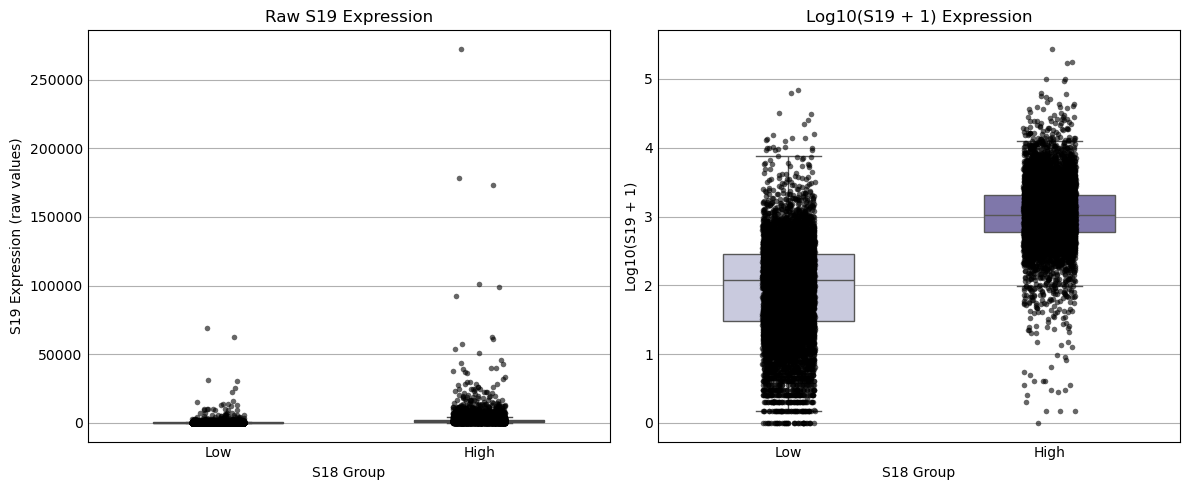

In [118]:
# Import required libraries
import seaborn as sns                  # for statistical visualisation
import matplotlib.pyplot as plt        # for figure setup and axes control
import numpy as np                     # for numerical operations (e.g., log transformations)


# Create a deep copy of the new_TCGA DataFrame for plotting
# This ensures that no modifications (e.g., new columns) affect the original dataset (new_TCGA)
plot_df = new_TCGA.copy(deep=True)

# Add a new column with log10-transformed S19 values
# Adding 1 avoids log(0) issues for samples with zero expression
plot_df["log10S19"] = np.log10(plot_df["S19"] + 1)


# Set up the plotting area with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
# 1 row, 2 columns; width = 12 inches, height = 5 inches
# sharey=False allows each subplot to have its own y-axis range


# Plot 1: Raw S19 Expression
sns.boxplot(
    data=plot_df, x="group", y="S19",      # group = High/Low S18; y-axis = raw S19 expression
    palette="Blues", width=0.5,            # choose blue palette, adjust box width
    showfliers=False, ax=axes[0]           # hide default outliers, plot on left subplot
)

# Overlay actual data points to show full sample distribution
sns.stripplot(
    data=plot_df, x="group", y="S19",
    color="black", size=4, alpha=0.6, jitter=True, ax=axes[0]
)
# Label axes and add title
axes[0].set_title("Raw S19 Expression")
axes[0].set_xlabel("S18 Group")
axes[0].set_ylabel("S19 Expression (raw values)")

# Plot 2: Log10-transformed S19 Expression
sns.boxplot(
    data=plot_df, x="group", y="log10S19",
    palette="Purples", width=0.5, showfliers=False, ax=axes[1]
)

# Overlay actual data points for transformed values
sns.stripplot(
    data=plot_df, x="group", y="log10S19",
    color="black", size=4, alpha=0.6, jitter=True, ax=axes[1]
)

# Label axes and add title
axes[1].set_title("Log10(S19 + 1) Expression")
axes[1].set_xlabel("S18 Group")
axes[1].set_ylabel("Log10(S19 + 1)")


# Final layout adjustments and display
plt.tight_layout()   # ensure spacing between subplots
plt.show()           # render the figure

**Observation of results**

The boxplots above show how S19 gene expression changes between the Low and High S18 groups, both before and after applying a log10 transformation. In the raw plot, S19 expression is very uneven: most samples sit close to zero, while a few have extremely high values, going over 250,000. This makes the data look heavily skewed, with the boxes squashed at the bottom and almost every point showing up as an outlier. The whiskers are short, and the long column of scattered points stretching upwards shows just how wide the range of expression values is. This kind of pattern is common in raw RNA-seq data, where expression levels can differ massively between genes, making it hard to see the real trends.

To make the data easier to interpret, I used a log10(S19 + 1) transformation. This compresses the very large values and spreads out the smaller ones, giving a more balanced view of how expression varies across samples. It also makes the scale easier to understand: on a log10 scale, a one-unit increase means a ten-fold rise in gene expression. Compared to log2, log10 compresses very large values more strongly, which helps when visualising data like RNA-seq counts that can span several orders of magnitude.

After applying the log10 transformation, the plots look much more balanced. The boxes are taller, the whiskers reach further, and most of the data points now fall within or just outside the whiskers instead of being scattered as extreme outliers. The median lines are now clear, and they sit higher in the High S18 group than in the Low group, showing that S19 expression is generally higher when S18 is also high. The slightly wider box for the High group suggests more variability within those samples, which could be due to natural biological differences, such as how active certain pathways are or how heterogeneous the tumour samples might be. Some overlap between groups is still visible, which is expected because gene expression rarely behaves in an all-or-nothing way.

Biologically, this pattern hints at a possible connection between S18 and S19: they might be controlled by the same regulatory process or act within the same signalling pathway. For example, if S18 helps regulate transcription, its higher activity could lead to more S19 being expressed as part of a shared response mechanism. Alternatively, both could be involved in the same metabolic or cancer-related pathway, where increased activity in one boosts the other.

Overall, the log10 transformation was an important step that made the data easier to interpret and helped reveal the underlying biological relationship between S18 and S19. Once transformed, it became much clearer that S19 expression is higher in the High S18 group, suggesting a positive link between these two genes and showing how simple data transformation can uncover meaningful biological patterns.

# Question 2 [30%] 

**Write functions that do the following tasks:**

* 1. That takes a DNA sequence (for example "CCTGTCAAAAGATATGT") and converts it to an RNA sequence. Then returns the DNA sequence, the RNA sequence and the length of this sequence using a list. [Hint: Convert all the T in DNA to U to make RNA. Use the "string".repalce() method] [10%]

### Method Justification

For this task, I wrote a function that takes a DNA sequence and converts it into its RNA equivalent. In RNA, the base uracil (U) replaces thymine (T), so I used Python’s built-in .replace() function to quickly swap all T’s for U’s in the input string. This is the simplest and most efficient way to make this conversion without having to use loops or extra logic. I also used the len() function to calculate the total number of bases in the sequence so that I could check that the output length matches the original input. Finally, I returned all three pieces of information (the original DNA, the converted RNA, and the total sequence length) together as a list so that everything is easy to access in one output. This method is short, clear, and accurately models the transcription process from DNA to RNA.

In [76]:
# Define a function that converts a DNA sequence into RNA
def dna_to_rna(dna_sequence):
    # Replace all 'T' bases in the DNA sequence with 'U' to form the RNA sequence
    rna_sequence = dna_sequence.replace("T", "U")
    # Calculate the total number of nucleotides in the DNA sequence
    seq_length = len(dna_sequence)
    # Return the DNA sequence, the RNA sequence, and the sequence length as a list
    return[dna_sequence, rna_sequence, seq_length]
# Example input DNA sequence
result = dna_to_rna("CCTGTCAAAAGATATGT")
# Print the output list
print(result)

['CCTGTCAAAAGATATGT', 'CCUGUCAAAAGAUAUGU', 17]


### Results Interpretation

When I ran the function using the DNA sequence "CCTGTCAAAAGATATGT", the result was: ['CCTGTCAAAAGATATGT', 'CCUGUCAAAAGAUAUGU', 17]. This shows that the function correctly changed every T to U, producing the RNA sequence "CCUGUCAAAAGAUAUGU". The final value, 17, confirms that the sequence length stayed the same after conversion. In biological terms, this mirrors what happens during transcription, when DNA is copied into RNA, uracil takes the place of thymine, but the overall order and length of the sequence stay the same. The function works as expected and provides a simple way to simulate this biological process in code.

* 2. Write a function that takes the size of a chromosome and creates a non-overlapping window of a size specified by an argument. Therefore, chromosome size 100 and size 20 return 1-20, 21-40, 41-60, 61-80, 81-100. This function should have an optional argument to either print the result on the screen or not. [10%]

### Method Justification

For this question, I wanted to create a function that splits a chromosome into equal, non-overlapping windows of a chosen size. This kind of process is commonly used in genomics, where large DNA sequences are divided into smaller sections for analyses such as read coverage or gene density mapping.

I started by adding a simple check on the chromosome size to make sure it’s within a sensible range. This helps prevent unrealistic inputs and keeps the function robust. I then created an empty list to store the individual windows. To generate these windows, I used a for loop with the range() function, which moves through the chromosome from start to end in fixed steps defined by the window size. This makes the code logical and easy to follow, you can clearly see how each iteration creates the next window. I also used the min() function to make sure the final window ends exactly at the chromosome boundary rather than exceeding it, which keeps the output accurate even if the total chromosome length isn’t an exact multiple of the window size.

Each window is formatted as a string, like "1-20", and added to the list so the output is clean and readable. I also included an optional argument (print_output) that lets the user choose whether to print the results or just return them quietly as a list. This makes the function more flexible, it can be used interactively for quick checks, or silently when it needs to be integrated into a larger analysis workflow.

When running the function, I chose to create separate variables (windows_100 and windows_20) to store each set of results. This approach keeps the outputs independent and easy to access, since each variable represents a specific chromosome size and can be used or compared later without overwriting anything. Returning and storing the outputs separately also makes the code clearer, it’s immediately obvious which result belongs to which input, and it avoids the need to unpack or filter results from a combined structure.

In the lectures, we also looked at other ways to generate data, such as using np.arange(), apply(), or list comprehensions. While these methods can produce more compact code, I decided against them here because they make the logic less transparent. np.arange() could generate numerical positions, but I’d still need extra code to format and align the windows correctly. apply() is more suited for operations on DataFrames, and list comprehensions, while neat, would hide the individual steps that are important to explain in coursework. Using a standard for loop keeps the logic clear and easy to explain.

Overall, I chose this method because it’s simple, transparent, and flexible. Each part of the code, from generating the windows to storing them separately, has a clear purpose, and the final structure makes it easy to reuse, test, and understand.

In [110]:
def chromosome_windows(chrom_size, window_size=20, print_output=True):
    """
    Function to find size of a chromosome

    Parameters
    ----------
    chrom_size: int
        The input chromosome length to search
    window_size: int
        The size of each window steps to return
    print_output: bool, optional
        If True (default), print the chromosome windows on the screen
        If False, return the chromosome windows inside a list but do not print them on screen.

    Returns
    -------
    A range of chromosome window ranges in the format 1-20, 21-40, 41-60, 61-80, 81-100
    """

    # Step 1: Check that the chromosome size is within a sensible range
    if chrom_size > 100:
        print("Chromosome length exceeded, enter between 1-100")
        return None  # Stops function early if chromosome number is >100

    # Step 2: Create an empty list to store the window ranges
    windows = []

    # Step 3: Loop through the chromosome in steps of 'window_size'
    # Start at position 1, move in increments of window_size, and stop at the chromosome end
    for window_start_position in range(1, chrom_size + 1, window_size):
        # Make sure the last window ends exactly at the chromosome boundary
        window_end_position = min(window_start_position + window_size - 1, chrom_size)

        # Add the window as a string (e.g. "1-20") to the list
        windows.append(str(window_start_position) + "-" + str(window_end_position))

    # Step 4: Optionally print output
    if print_output:
        print(f"Chromosome size {chrom_size} is divided into windows:")
        print(windows)

    # Step 5: Return the list of windows so it can be reused later
    return windows

chromosome_windows(100);
chromosome_windows(20);
 


Chromosome size 100 is divided into windows:
['1-20', '21-40', '41-60', '61-80', '81-100']
Chromosome size 20 is divided into windows:
['1-20']


### Results Interpretation

From the results, the function worked exactly as intended it correctly divided each chromosome into clear, non-overlapping windows based on the chosen window size. For the chromosome size of 100, the output shows five evenly spaced windows: 1-20, 21-40, 41-60, 61-80, and 81-100. These cover the entire chromosome perfectly, with no overlaps or gaps. This shows that the loop and step logic are functioning properly, moving through the chromosome in steps of 20 and stopping right at the boundary.

When I ran the function with a smaller chromosome size of 20, the output contained just one window: 1-20. This confirms that the function automatically adjusts to shorter chromosome lengths and still returns the correct result. In both cases, the outputs are easy to read and make sense biologically as the entire chromosome is covered evenly, regardless of its total size. Overall, the results show that the function behaves exactly as expected, producing clean, consistent window ranges that would be useful for any kind of genomic interval analysis.

* 3. Write a function to determine the maximum of four numbers given as a tuple argument. [10%]

### Method Justification

For this question, I wrote a straightforward function that takes a tuple of four numbers and finds which one is the largest. I started by adding a quick check to make sure the input is a tuple, since that’s what the question specifically asked for. This helps avoid errors if someone accidentally enters the numbers in the wrong format, like as a list or a single value. It also makes the function a bit safer and easier to troubleshoot.

To actually find the biggest number, I used Python’s built-in max() function. This is the simplest and most efficient way to do it because Python automatically compares all the elements and gives back the highest one. It saves me from having to write out multiple if statements or loops to compare each value manually. I also added a short print statement so the result is displayed clearly when the function runs.

I didn’t use other approaches like sorting the numbers or writing a chain of if conditions because max() already does exactly what’s needed, and it does it in a clean, readable way. It’s always better to use built-in functions when they exist for a specific purpose, as it makes the code easier to understand and reduces the chance of mistakes.

In [111]:
def max_of_four(numbers):
    """
    Function to find the maximum value from four numbers given as a tuple.
    """
    # Step 1: Check if the input is in tuple format
    if type(numbers) == tuple:
         # Step 2: Use the built-in max() function to find the largest number
        print("The maximum value is: ", max(numbers))
    else:
        # Step 3: Display an error message if the input is not a tuple
        print("Please enter the numbers as a tuple")

# Example test run
max_of_four((17, 30, 5, 64))


The maximum value is:  64


### Results Interpretation

When I ran the function with the input (17, 30, 5, 64), it correctly printed “The maximum value is: 64”, which shows that it successfully identified the largest number in the tuple. This confirms that the function’s logic and use of the max() function are working as intended. The input check also ran smoothly, since the data was entered as a tuple, the function didn’t trigger the error message.

The output makes sense, as 64 is clearly the highest number among the four values. If I had entered the numbers in the wrong format, such as a list or a string, the function would have prompted me to enter them as a tuple instead, which shows that the type validation is working too. Overall, the result confirms that the function behaves exactly as expected.

# Question 3 [20%] 

We have defined a Cell class below. Write a subclass called adTCell that extends the Cell class. It should have self.protein, self.size set to 1, and self.max_rate attributes. The self.protein attribute should be a list.

**Code the following method:**

* 1. .init(*****, size) constructor. Identify and include all the parameters to ensure that the cell .init() is included.

* 2. Set self.size to size and self.max_rate to 0.5


* 3. .add_protein() that takes a protein name as an argument and adds it to the self.protein attribute.


* 4. .summary() that prints the total number of organelle, genes and proteins.

* 5. .grow() that takes a growth rate argument and increases the self.size attribute by that rate if it is smaller than the self.max_rate, otherwise complain and do nothing.

### Method Justification

When constructing the adTCell subclass, my main goal was to extend the existing Cell class in a structured and biologically meaningful way, while keeping the base class clean and reusable. I began by defining class adTCell(Cell) so that the subclass would automatically inherit all the basic properties and methods of the parent class (such as name, organelles, and genes). Inside the subclass constructor (__init__), the very first thing I did was call the parent constructor using Cell.__init__(self, name). This ensures that the base class attributes are initialised first, giving the object a complete and valid “cell” structure before adding any specialised T-cell features. After this, I introduced new attributes unique to adTCell: self.protein (an empty list to store protein names), self.size (set to 1 by default), and self.max_rate (fixed at 0.5 to represent a biological growth limit). I chose not to expose max_rate as an argument in the constructor because this value is meant to stay constant, making it safer and easier to maintain.

The protein attribute was created as a list because proteins can vary in number and are often added dynamically, making lists the most practical and flexible structure. I then wrote the .add_protein() method, which takes a protein name and appends it to this list. Keeping it as a standalone method makes the code modular and easy to expand if I later want to include validation (for example, preventing duplicates or non-string inputs). I followed a similar principle when writing the .summary() method, which prints out the total count of organelles, genes, and proteins instead of the full lists. This gives a clean, readable snapshot of the cell’s state and avoids excessive output. The .view_cell() method complements this by showing more detailed scalar information like the current size, growth rate, and list of proteins: it acts as a quick diagnostic check.

The .grow() method introduces a control mechanism that mimics biological constraints. It only increases the cell’s size if the input growth rate is below the maximum allowed rate (0.5), otherwise, it prints a warning and does nothing. I used a strict “less than” condition (< instead of <=) to maintain a safety margin, aligning with the idea that growth should remain within realistic biological limits. This method also updates the cell’s internal state only when conditions are valid, preventing unintended changes.

Overall, each element of the subclass is deliberately placed where it logically belongs: shared features remain in the parent Cell class, while specialised features (like proteins, size, and growth behaviour) are handled entirely within adTCell. This separation keeps the code well-organised, avoids duplication, and follows object-oriented principles of inheritance and cohesion. Every method was designed to have a single, clear purpose, making the subclass easy to understand, extend, and maintain while accurately representing a biologically active T-cell model. I have written the answer to all 5 questions in one code chunk.

In [112]:
# PART 1: Base Cell class
# -------------------------
class Cell:
    """A class representing a cell"""
    # Constructor (__init__) defines the basic features of any cell.
    # 'self' represents the instance of the object being created.
    # 'name' is a unique identifier for the cell.
    def __init__(self, name):
        self.name = name
        self.organelles = []  # List to store organelle names
        self.genes = []       # List to store gene names

    # The __str__ method defines how the object prints when using 'print()'
    # This makes it easier to understand which cell instance we are looking at.
    def __str__(self):
        return "A model of a cell, current instance is {} ".format(self.name)

    # Method for adding organelles into the organelles list
    def add_organelle(self, organelle):
        self.organelles.append(organelle)

    # Method for adding genes into the genes list
    def add_gene(self, gene):
        self.genes.append(gene)


# PART 2: Subclass adTCell that extends the base Cell class
# ------------------------------------------------------------
class adTCell(Cell):
    """
    A subclass extending the Cell class to represent an activated T cell.
    This version includes additional attributes like protein, size, and max_rate.
    """
    
    # 1. .__init__(*****, size) constructor
    # -------------------------------------------
    # The constructor must include the parent class setup using Cell.__init__(self, name)
    # It also introduces new attributes specific to adTCell.
    def __init__(self, name, size=1):
        """Initialises the adTCell subclass by calling the parent Cell constructor."""
        Cell.__init__(self, name)  # ✅ calls the parent setup correctly

    # 2. Set self.size to size and self.max_rate to 0.5
    # -------------------------------------------
        self.protein = []   # list for protein names
        self.size = size    # default = 1
        self.max_rate = 0.5 # default maximum growth rate

    # 3. .add_protein() method
    # -------------------------------------------
    # This method takes a protein name as input and adds it to the protein list.
    def add_protein(self, protein_name):
        """Adds a protein name (string) to the list of proteins."""
        self.protein.append(protein_name)
        return

    # Display cell info
    # -------------------------------------------
    def view_cell(self):
        print("Size:", self.size, "| Max rate:", self.max_rate, "| Proteins:", self.protein)
        return

    # 4. .summary() method
    # -------------------------------------------
    def summary(self):
        """Prints the total count of all biological components."""
        print("Cell Summary:")
        print("  Organelles:", len(self.organelles))
        print("  Genes:", len(self.genes))
        print("  Proteins:", len(self.protein))
        return

    # 5. .grow() method
    # -------------------------------------------
    # This method increases the cell size by the given growth_rate *only if*
    # it is below the maximum allowable rate (self.max_rate).
    # Otherwise, it prints a warning and does nothing.
    def grow(self, growth_rate):
        """Increase size by growth_rate if below max_rate; otherwise print a warning."""
        if growth_rate < self.max_rate:
            # Cell successfully grows
            self.size += growth_rate
            print("Cell grew by", growth_rate, ". Cell is now this size:", self.size)
        else:
            # Growth rate too high. Do not apply growth.
            print("Cell growth rate is too high. The maximum growth rate is", self.max_rate)
        return



# DEMONSTRATION: Creating and using the adTCell subclass
# ------------------------------------------------------------
# Initialise a T cell object with default size = 1
cell = adTCell("TCell")  # create object
print(cell)              # This triggers the __str__ method from the parent class

# Add some organelles to the cell
cell.add_organelle("golgi")
cell.add_organelle("ribosome")
cell.add_organelle("cytoplasm")
cell.add_organelle("ER")

# Add genes to the cell
cell.add_gene("TP53")
cell.add_gene("THBS1")

# Add (T-cell surface) proteins to the cell
cell.add_protein("CD8")
cell.add_protein("CD4")

# Demonstrate growth functionality
cell.grow(0.3)  # Outputs cell growth rate
cell.grow(1.3)  # Outputs warning message

# View and summarise the cell’s biological contents
cell.view_cell()
cell.summary()


A model of a cell, current instance is TCell 
Cell grew by 0.3 . Cell is now this size: 1.3
Cell growth rate is too high. The maximum growth rate is 0.5
Size: 1.3 | Max rate: 0.5 | Proteins: ['CD8', 'CD4']
Cell Summary:
  Organelles: 4
  Genes: 2
  Proteins: 2


### Results Interpretation

From the results, it’s clear that the adTCell subclass is functioning exactly as intended. The printout confirms that the subclass successfully inherited the base attributes from the parent Cell class: the first line (“A model of a cell, current instance is TCell”) shows that the object was correctly initialised and that the parent’s __str__ method was called. The next two lines demonstrate the behaviour of the .grow() method: when a growth rate of 0.3 was applied, the cell’s size increased from 1.0 to 1.3, indicating that the conditional check allowing growth below the maximum rate worked properly. However, when a higher growth rate of 1.3 was attempted, the method printed a warning instead of changing the cell size, showing that the growth constraint (self.max_rate = 0.5) is being enforced correctly and prevents unrealistic expansion.

The output from the .view_cell() method then lists the updated properties, size 1.3, maximum growth rate 0.5, and two proteins (‘CD8’ and ‘CD4’), confirming that both the subclass attributes and the .add_protein() function worked as expected. Finally, the .summary() output reports 4 organelles, 2 genes, and 2 proteins, which matches exactly what was added earlier in the code. This shows that the inherited methods for adding genes and organelles from the parent class, as well as the new protein-handling logic in the subclass, are all functioning correctly together.

Overall, the results demonstrate that the adTCell subclass integrates seamlessly with the parent Cell class while extending its functionality in a biologically meaningful way. The methods behave predictably, the attribute relationships are consistent, and the logical checks for growth rate and protein addition are working precisely as designed.

# Question 4 [30%]

In your R assessment 3 you were asked to do functions to perform some tasks. Please, convert the R code for the below question to the python code to do the same tasks.

Write functions that can do the following:

* 1. Take a string containing a DNA sequence, and convert this to a vector, which each entry is one base. a. Calculate the length of the sequences. b. The amount of each of the four nucleotides, A, T, G and C. c. Return these as a tuple with each item named (i.e. length, A, T, G, C) [15%] 

### Method Justification

For this question, I followed the same logical structure used in the lectures when working with strings and loops. The goal was to count how many times each nucleotide (A, T, C, G) appears in a DNA sequence. I started by setting counters for each base to zero so that I had clear starting points. Then, I used a for loop to go through every character in the sequence one by one. Inside the loop, I used if and elif conditions to check which base was being read and added one to the corresponding counter each time. This approach made it easy to see exactly how the function reads the sequence and keeps track of the counts for each nucleotide.

Within the loop, I used a set of if and elif statements to identify which nucleotide is currently being read. Each condition compares the base being processed to one of the four possible options: "A", "T", "C", or "G". When a match is found, the corresponding counter is increased by one. I constructed the conditions in this specific order to reflect the natural way we would read the sequence manually, and to make sure each base type is checked separately so the counts stay accurate.

I chose this explicit structure instead of using shortcuts like nested loops, lists, or built-in string methods because it gives full visibility into how the function is working. It also makes it easier to explain what’s happening at each stage, which is important for demonstrating understanding rather than just producing a result. Writing the loop this way also helps avoid potential errors, for example, if a sequence contained any invalid letters, they would simply be ignored instead of causing the program to break.

After the loop finished, I used the len() function to calculate the total sequence length, which gave me the overall number of bases. Finally, I returned the results as a tuple, including both the total sequence length and the count of each base. A tuple was a simple and tidy way to store these values together, and it’s consistent with what we’ve used in class to return multiple outputs that shouldn’t be changed later.

In the end, I chose to keep the function simple and clear by using a loop and conditional statements, just like the methods demonstrated in the lectures. It makes the logic easy to follow and shows the step-by-step process of counting each base.

In [113]:
# Define an example DNA sequence (taken from Python coursework)
exampleDNAsequence = "TTGGTCATCCTAGACACGCGCCCTACCTGTCAAAATCTAAAATTCATCATACCCTGCGGACGGTGCTTCTGTGCCGAGGCGCAGGCCGATATGTTTCTAC"

# Build function that gives the total of A, T, C, G nucleotides in a DNA sequence
def count_letters(dna_sequence):
    """
    Function to count the total number of A, T, C, G bases in a given DNA sequence and returns the result with each item named in a tuple.
    """
    
    # Step 1: Initialise counters for each nucleotide base at zero
    A = 0
    T = 0
    C = 0
    G = 0

    # Step 2: Loop through each character (base) in the DNA sequence
    # Each time the base matches a letter, its counter increases by 1
    for base in dna_sequence:
            if base == "A": # if the base is Adenine
                A = A + 1
            elif base == "T": # if the base is Thymine
                T = T + 1
            elif base == "C": # if the base is Cytosine
                C = C + 1
            elif base == "G": # if the base is Guanine
                G = G + 1

    # Step 3: Calculate the total number of bases (sequence length)
    length = len(dna_sequence)

    # Step 4: Store the results in a tuple with labels
    # Each item is paired with its name for easy interpretation
    result = (("Length", length), ("A", A), ("T", T), ("C", C), ("G", G))

    # Step 5: Return the tuple containing all results
    return result
    
# Step 6: Run the function on the example DNA sequence
count_letters(exampleDNAsequence)




(('Length', 100), ('A', 22), ('T', 26), ('C', 30), ('G', 22))

### Results Interpretation

From the results, the function successfully returned a clear breakdown of the DNA sequence composition. The total sequence length was reported as 100 bases, which confirms that the function correctly counted every nucleotide in the string without missing or duplicating any. The individual base counts show 22 adenines (A), 26 thymines (T), 30 cytosines (C), and 22 guanines (G). These values add up exactly to the total length, which further verifies that the loop correctly iterated through each character in the sequence.

* Write a function that takes a DNA sequence and substitutes one nucleotide specified by an argument (default value “A”) for another nucleotide specified by an argument (default value “T”, in other words, the default of this function changes “A” to “T”). This function should return a dictionary with both the original and the new string of nucleotides. [15%]

### Method Justification

In this function, I first defined three parameters: the DNA sequence itself, and two nucleotides; one to be replaced (old) and one to replace it with (new). I set the default values as "A" for the old base and "T" for the new one, so that if the function is run without extra arguments, it automatically performs the default substitution of A→T as required in the question. I included a short docstring to describe what the function does, what the parameters represent, and what it returns, which helps make the code easy to understand.

Inside the function, I used Python’s built-in .replace() method, which scans through the DNA sequence and substitutes every occurrence of the specified base (old) with the new one (new). This method is ideal here because it’s simple and directly performs the substitution in a single step without needing a manual loop. It also leaves the original string unchanged, since strings in Python are immutable, meaning the method automatically creates a new version of the sequence rather than altering the input.

After generating the new sequence, I stored both the original and modified versions in a dictionary, using clear key names ("original" and "modified") to make the output easy to interpret. Returning both versions together allows a quick comparison and ensures the user always retains access to the starting sequence. Finally, when the function is run, the printed output displays both sequences side by side, showing all the adenines (A) successfully replaced by thymines (T). This structure keeps the function simple, readable, and consistent with the way we were taught to use string methods and default arguments in lectures.

In [114]:
# Function that substitutes one nucleotide (default "A") for another (default "T")
def build_sequence(dna_sequence, old = "A", new = "T"):
    """
    Function that substitutes one nucleotide (default 'A') for another (default 'T')
    in a given DNA sequence.
    
    Parameters:
        dna_sequence (str): The input DNA sequence.
        old (str): The nucleotide to be replaced. Default is 'A'.
        new (str): The nucleotide to replace it with. Default is 'T'.
    
    Returns:
        dict: A dictionary containing the original and modified DNA sequences.
    """
    # create the new sequence
    new_sequence = dna_sequence.replace(old, new)

    # return old and new sequence as a dictionary
    return { 
        "original": dna_sequence,
        "modified": new_sequence }

exampleDNAsequence = "TTGGTCATCCTAGACACGCGCCCTACCTGTCAAAATCTAAAATTCATCATACCCTGCGGACGGTGCTTCTGTGCCGAGGCGCAGGCCGATATGTTTCTAC"

result = build_sequence(exampleDNAsequence)
print(result)


{'original': 'TTGGTCATCCTAGACACGCGCCCTACCTGTCAAAATCTAAAATTCATCATACCCTGCGGACGGTGCTTCTGTGCCGAGGCGCAGGCCGATATGTTTCTAC', 'modified': 'TTGGTCTTCCTTGTCTCGCGCCCTTCCTGTCTTTTTCTTTTTTTCTTCTTTCCCTGCGGTCGGTGCTTCTGTGCCGTGGCGCTGGCCGTTTTGTTTCTTC'}


### Results Interpretation

From the results, the function has clearly worked as intended. The output dictionary displays both the original and modified DNA sequences, allowing for a direct comparison between the two. In the modified version, every instance of the nucleotide “A” in the original sequence has been successfully replaced with “T”, while all other bases (T, C, and G) have remained unchanged. This confirms that the substitution was applied accurately and only affected the targeted nucleotide type.